# 5 &mdash; Frequency-dependent targets: App. B.8 &ndash; B.12 (+ the rotation family)

B.1&ndash;B.7 pin $\sigma_\mathrm{out}$ at a **single** $\Omega$, where the decay ratios
$\tilde\kappa_i$ are inert. The five targets here are pinned on a **grid**, which is exactly
what turns the $\tilde\kappa_i$ into live optimisation variables &mdash; the headline
difference to AUTOSCATTER (Sec. 3, App. A.4(c)).

* **B.8** squeeze-angle rotation (filter cavity) &rarr; the phase-sensitive Nambu cross term
  $\sigma_{xp}(\Omega)$; invisible to any $N\times N$ (phase-preserving) reduction.
* **B.9** bandpass sideband squeezing &rarr; a spectral *window*: detuning sets its position,
  $\tilde\kappa$ its width.
* **B.10** flat-top order $n$ &rarr; spectral degree vs mode count: the band-edge order is
  what costs modes.
* **B.11** band-limited EPR &rarr; entanglement with a *bandwidth*, written on the joint
  quadratures (quadratic-form pins).
* **B.12** notch squeezing &rarr; a dip needs one resonance; a dip *with a hole in it* needs
  the interfering partner.

Then three **extensions of B.8** (Sec. 8.7), each breaking one property B.8 keeps &mdash; the
rotation family:

* **B.8-imp** impure rotation &rarr; a prescribed purity spectrum $\mu(\Omega) \geq 1$ pushes
  the fit **off** the pure-state variety $\det \sigma_\mathrm{out} = 1$, which takes *added
  noise*: the intrinsic losses $\gamma_i$ go live.
* **B.8-nm** non-monotone rotation &rarr; a turning point in $\theta(|\Omega|)$; rotation
  **shape** as the counted resource.
* **B.8-wind** prescribed winding &rarr; more accumulated sweep than one mode can supply;
  rotation **magnitude** as the counted resource.

Two conventions these targets rely on:

* **Grids run over $\Omega \geq 0$.** The symmetrised spectrum obeys
  $V(-\Omega) = V(\Omega)^T$, so every diagonal entry is automatically even in $\Omega$;
  pinning $-\Omega$ is redundant and pinning a non-even shape asks for something no device
  can emit.
* **Shape targets are matched to $\sim 10^{-8}$, not $10^{-10}$.** B.9&ndash;B.12 carry that
  tolerance in their `GalleryProblem`; B.8 is exact, because its target is built from the
  closed form a single detuned lossless mode actually emits.

Every fit here is an *active* target sitting near the parametric-oscillation threshold, so the
Sec. 5 stability constraint does real work: witnesses come back with
$\max \mathrm{Re}\,\mathrm{eig}(\tilde M)$ close to zero from below.

**Oracle vs search.** Most cells below run the **oracle** (Sec. 4) on the fully connected
graph: it answers *can this many modes realise the target*, which is what the mode-count ladder
needs. B.8, B.9 and B.10 additionally run the full **Sec. 6 discovery** &mdash; the
breadth-first walk down the graph lattice that returns the two libraries and the *irreducible*
graphs. Those three search cells are the slow part of this notebook (B.8 ~1 s, B.9 ~8 min,
B.10 ~8 min): a spectral oracle call costs ~1 s against ~10 ms for the single-point targets of
notebooks 1&ndash;4, and a 2-mode lattice has $3^6 = 729$ graphs in it. A 3-mode lattice
($3^{12} \approx 5\times10^5$) is out of reach for a full BFS, which is why B.11 and B.12 stop
at the oracle here; use `greedy_minimal_subgraph` / `minimal_valid_subgraphs` below the fully
connected graph for those.

Script version: `examples/05_spectral_gallery.py` (add `--search` for the discovery runs).

In [1]:
# In case you are using Google Colab, this cell installs AutoGaussian
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install "git+https://github.com/Fouriersaur/AutoGaussian.git#subdirectory=autogaussian"
else:
    # running from a clone: put the package root on sys.path
    import os
    sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt

from autogaussian import (
    CooperativityBudget,
    CovarianceArchitectureOptimizer,
    duan_sum,
    parameter_summary,
    solution_table,
)
from autogaussian.gallery import (
    accumulated_rotation,
    band_limited_epr,
    bandpass_squeezer,
    butterworth_dip,
    duan_of_band_limited_epr,
    filter_cavity_angle,
    flat_top_squeezer,
    impure_rotation,
    lorentzian_dip,
    non_monotone_rotation,
    notch_squeezer,
    rotation_purity,
    rotation_spectrum,
    single_mode_winding_ceiling,
    squeeze_angle,
    squeeze_angle_rotation,
    winding_rotation,
)

SUMMARY = []
NUM_TESTS = 15
SEED = 7


def fit(problem, num_auxiliary_modes, seed=SEED, num_tests=NUM_TESTS,
        show_parameters=True, **overrides):
    '''Oracle on the fully connected graph with this many modes.'''
    kwargs = problem.optimizer_kwargs(kwargs_optimization={"num_tests": num_tests})
    kwargs.update(overrides)          # e.g. intrinsic_losses=False for B.8-imp
    optimizer = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=seed,
        make_initial_test=False, **kwargs)
    success, infos = optimizer.test_graph(optimizer.space.fully_connected())
    info = next((i for i in infos if i["success"]),
                min(infos, key=lambda i: i["loss_reached"]))
    print("%i mode(s): %-12s loss = %.2e   max Re eig(M~) = %+.4f"
          % (optimizer.num_modes, "VALID" if success else "no witness",
             info["loss_reached"], info["max_real_eigenvalue"]))
    if success and show_parameters:
        # the converged device: cooperativities / phases / detunings / kappa~
        print(parameter_summary(info, optimizer.space,
                                optimizer.reduce_graph(info["x"])))
    return optimizer, success, info


def mode_count_ladder(problem, counts, **overrides):
    '''Fit the same target with growing mode counts; return the first witness.'''
    winner = None
    for num_auxiliary_modes in counts:
        optimizer, success, info = fit(problem, num_auxiliary_modes, **overrides)
        if success and winner is None:
            winner = (optimizer, info, optimizer.num_modes)
    return winner


def spectrum_of(optimizer, x, omegas, row=0, col=0):
    return np.array([np.real(optimizer.oracle.covariance(x, w))[row, col] for w in omegas])


def search(problem, num_auxiliary_modes, seed=SEED, num_tests=10,
           parameter_limit=6):
    '''Full Sec. 6 two-library discovery: BFS down the graph lattice.'''
    t0 = time.time()
    optimizer = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=seed,
        make_initial_test=False,
        **problem.optimizer_kwargs(kwargs_optimization={"num_tests": num_tests}))
    print("lattice: %i modes, %i slots, max complexity %i"
          % (optimizer.num_modes, optimizer.space.num_slots, optimizer.space.max_complexity))
    irreducibles = optimizer.perform_breadth_first_search(progress=False)
    libraries = optimizer.libraries
    print("\n%i irreducible graph(s), %i top-level oracle calls, %.1f s"
          % (len(irreducibles), sum(optimizer.num_tested_graphs), time.time() - t0))
    for graph in irreducibles:
        solution = optimizer.solution_of(graph)
        print("   complexity %i:  %s%s"
              % (int(np.sum(graph)), ", ".join(optimizer.space.describe(graph)),
                 "" if solution is None else "   [loss %.2e, alpha %+.3f]"
                 % (solution["loss_reached"], solution["max_real_eigenvalue"])))
    # ... and the parameters behind each of them (Sec. 8 output)
    print()
    print(solution_table(optimizer, irreducibles, limit=parameter_limit))
    certified = sum(1 for e in libraries.invalid.values() if e.certified)
    print("\nlibraries: valid %i | invalid %i  (certified %i, uncertified %i)"
          % (len(libraries.valid), len(libraries.invalid), certified,
             libraries.n_uncertified()))
    return optimizer, irreducibles

## B.8 &mdash; frequency-dependent squeeze-angle rotation (filter cavity)

Fixed squeeze *magnitude*, rotating squeeze *axis*: the canonical GW-detector FDS target.
One lossless mode at $\Delta/\kappa = 1/2$ reflecting an $r$-squeezed input returns
$\det \sigma_\mathrm{out}(\Omega) = 1$ at **every** $\Omega$, with $\Omega$-independent
ellipse eigenvalues $(e^{-2r}, e^{+2r})$, while the axis sweeps $0 \to \pi/2$ &mdash; depth
untouched, angle rotated, as a lossless passive element must.

$\Delta/\kappa = 1/2$ is forced, not chosen: $\theta(0) = 0$ requires
$4\arctan(2\Delta/\kappa) = \pi$.

In [3]:
r, crossover = 0.6, 1.0
problem_b8 = squeeze_angle_rotation(r=r, crossover=crossover)
print(problem_b8.notes, "\n")

optimizer_b8, success_b8, info_b8 = fit(problem_b8, num_auxiliary_modes=0)

parameters = info_b8["parameters"]
print("\nrecovered device: Delta/kappa = %.6f, kappa~ = %.6f (= sqrt(2) Omega_c)"
      % (parameters["detunings"]["Delta_0/kappa_0"], parameters["decay_ratios"]["kappa~_0"]))
used = {k: v for k, v in parameters["cooperativities"].items() if v > 1e-12}
print("squeezing elements used:", used or "none (purely passive)")

B.8  squeeze angle sweeps 0 -> pi/2 across the band at fixed depth; crossover Omega_c <- detuning, rotation rate <- kappa~. Passive and lossless, so the output stays pure at every Omega. 



1 mode(s): VALID        loss = 6.78e-17   max Re eig(M~) = -0.7071
   graph: detuning Delta_0
   loss=6.78e-17   max Re eig(M~)=-0.7071
   detunings:       Delta_0/kappa_0=+0.5000
   decay_ratios:    kappa~_0=+1.4142

recovered device: Delta/kappa = 0.500000, kappa~ = 1.414214 (= sqrt(2) Omega_c)
squeezing elements used: none (purely passive)


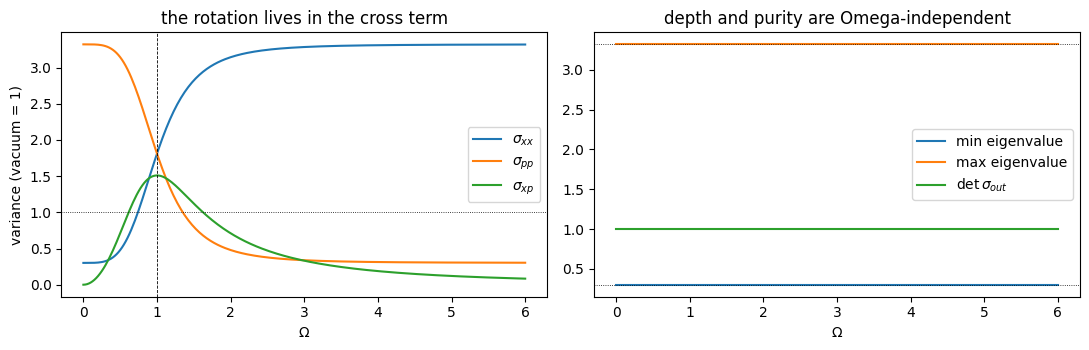

theta(0) = 0.0000, theta(Omega_c) = 0.7854, theta(inf) -> 1.5708
sigma_xp is nonzero and Omega-dependent -- that entry *is* the rotation, and it
does not exist in a phase-preserving N x N model.


In [4]:
grid = np.linspace(0.0, 6.0, 241)
V = np.array([np.real(optimizer_b8.oracle.covariance(info_b8["x"], w)) for w in grid])
eigenvalues = np.linalg.eigvalsh(V)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(grid, V[:, 0, 0], label=r"$\sigma_{xx}$")
axes[0].plot(grid, V[:, 1, 1], label=r"$\sigma_{pp}$")
axes[0].plot(grid, V[:, 0, 1], label=r"$\sigma_{xp}$")
axes[0].axhline(1.0, color="k", lw=0.6, ls=":")
axes[0].axvline(crossover, color="k", lw=0.6, ls="--")
axes[0].set_xlabel(r"$\Omega$"); axes[0].set_ylabel("variance (vacuum = 1)")
axes[0].set_title("the rotation lives in the cross term")
axes[0].legend()

axes[1].plot(grid, eigenvalues[:, 0], label="min eigenvalue")
axes[1].plot(grid, eigenvalues[:, 1], label="max eigenvalue")
axes[1].plot(grid, np.linalg.det(V), label=r"$\det \sigma_{out}$")
axes[1].axhline(np.exp(-2 * r), color="k", lw=0.6, ls=":")
axes[1].axhline(np.exp(+2 * r), color="k", lw=0.6, ls=":")
axes[1].set_xlabel(r"$\Omega$"); axes[1].set_title("depth and purity are Omega-independent")
axes[1].legend()
plt.tight_layout(); plt.show()

print("theta(0) = %.4f, theta(Omega_c) = %.4f, theta(inf) -> %.4f"
      % (filter_cavity_angle(0.0, crossover), filter_cavity_angle(crossover, crossover),
         filter_cavity_angle(1e6, crossover)))
print("sigma_xp is nonzero and Omega-dependent -- that entry *is* the rotation, and it")
print("does not exist in a phase-preserving N x N model.")
SUMMARY.append(("B.8 squeeze rotation", 1, "pure at every Omega, axis sweeps pi/2"))

### B.8 &mdash; the full Sec. 6 search

Everything above is the **oracle** (Sec. 4) run on the fully connected graph: it says *this
graph can do it*, not *this is the minimal device*. The discovery loop is the breadth-first
walk down the graph lattice (Sec. 6), which returns the two libraries and the irreducible
graphs. B.8's lattice is tiny (1 mode, 2 slots), so the whole search costs a second.

Watch what it finds: the target is a *squeezing* spectrum, and the minimal device contains **no
squeezing element at all** &mdash; a bare detuned passive mode, with all the squeezing supplied
by the declared input $\sigma_\mathrm{in}$. Nothing told the search that; it fell out of the
lattice walk.

In [5]:
optimizer_b8_search, irreducibles_b8 = search(problem_b8, num_auxiliary_modes=0)
print()
print(optimizer_b8_search.completeness_statement())

lattice: 1 modes, 2 slots, max complexity 3
start breadth-first search over 2 slots (max complexity 3)
test 1 graphs with 3 degrees of freedom:


test 1 graphs with 2 degrees of freedom:


test 1 graphs with 1 degrees of freedom:
test 1 graphs with 0 degrees of freedom:
valid: 2    invalid: 3 (certified 0, uncertified 3)    oracle calls: 53    escalations: 2
optimisation finished, list of irreducible graphs has 1 elements (3 uncertified rejections)

1 irreducible graph(s), 4 top-level oracle calls, 0.9 s
   complexity 1:  detuning Delta_0   [loss 6.78e-17, alpha -0.707]

1 valid graph(s), with the converged parameters:

#0  complexity=1  couplings=0  pumps=0
      detuning Delta_0
      loss=6.78e-17   max Re eig(M~)=-0.7071
      detunings:
         Delta_0/kappa_0      +0.5000
      decay_ratios:
         kappa~_0             +1.4142

libraries: valid 2 | invalid 3  (certified 0, uncertified 3)

The list of irreducible graphs is complete up to at most 3 false negatives (graphs rejected without a certificate):
    [default] on-site squeezing 0 (complex)
    [default] on-site squeezing 0 (real)
    [provisional] empty graph


## The squeeze-angle-rotation family &mdash; B.8-imp, B.8-nm, B.8-wind (Sec. 8.7)

B.8 asks for a rotating axis at **fixed depth** on a **pure** state, and one lossless detuned
mode delivers it exactly. Each target below breaks one of those properties and asks what the
break costs in hardware:

| target | what it breaks | the counted resource |
|---|---|---|
| **B.8-imp** | purity: $\det \sigma_\mathrm{out}(\Omega) = \mu(\Omega)^2 > 1$ | *added noise* &rarr; a live $\gamma_i$ |
| **B.8-nm** | monotonicity of $\theta(\lvert\Omega\rvert)$ | rotation **shape** &rarr; a coupled partner |
| **B.8-wind** | the size of the total sweep $\sum \lvert\Delta\theta\rvert$ | rotation **magnitude** &rarr; a mode |

**How these targets are written.** B.8 could be pinned from the closed form
$\theta(\Omega)$ of a single detuned mode. None of these three has such a closed form &mdash;
an impure or two-pole rotation is a ratio of quadratics whose angle and purity spectra are
exactly the symbolic-regression *outputs* of Sec. 7.2, never inputs. So they are written the
only honest way round: as the spectrum of a declared **reference device** (`rotation_device`),
evaluated through the forward map, with the prescribed quantity &mdash; purity spectrum,
turning point, total winding &mdash; *measured* off it. The fit never sees the reference, only
the pinned numbers.

The last two are the rotation-family analogues of B.10, so they are read the same way: a
**feasibility transition**, one mode short &rarr; $L > \mathrm{tol}$ on every restart (a
provisional, non-condemning INVALID, Sec. 6); add the mode &rarr; VALID. No exact closed-form
mode count is claimed.

### B.8-imp &mdash; impure rotation: the purity spectrum forces added noise

The same rotating axis as B.8 on an ellipse that is no longer pure. $\mu(\Omega) = \sqrt{\det
\sigma_\mathrm{out}}$ peaks near the crossover, where the sideband dwells longest inside the
cavity and absorbs the most vacuum &mdash; the most faithful "as-measured" member of the
family, because real filter cavities are lossy.

A lossless **single** mode is all-pass: it rotates the input ellipse symplectically, so
$\det \sigma_\mathrm{out} = 1$ for *every* detuning and decay ratio and no amount of tuning
reaches $\mu > 1$. Freeing $\gamma_0$ fixes that in one parameter.

In [6]:
loss = 0.2
problem_imp = impure_rotation(loss=loss)
print(problem_imp.notes, "\n")

optimizer_imp, success_imp, info_imp = fit(problem_imp, num_auxiliary_modes=0)
print("recovered: gamma_0 = %.6f (declared %.2f), Delta/kappa = %.6f, kappa~ = %.6f"
      % (info_imp["parameters"]["intrinsic_losses"]["gamma_0"], loss,
         info_imp["parameters"]["detunings"]["Delta_0/kappa_0"],
         info_imp["parameters"]["decay_ratios"]["kappa~_0"]))

print("\nsame graph with the losses frozen (a lossless single mode):")
_, success_lossless, info_lossless = fit(problem_imp, num_auxiliary_modes=0,
                                         intrinsic_losses=False)
print("   -> %s, best loss %.2e -- it is stuck on the det = 1 variety"
      % ("VALID" if success_lossless else "no witness", info_lossless["loss_reached"]))

B.8-imp  rotating axis at prescribed purity mu(Omega) in [1.020, 1.199] (most mixed near Omega_c = 1); det sigma_out > 1 needs a live intrinsic loss gamma_i, not just detuning. 



1 mode(s): VALID        loss = 1.34e-09   max Re eig(M~) = -0.8485
   graph: detuning Delta_0
   loss=1.34e-09   max Re eig(M~)=-0.8485
   detunings:       Delta_0/kappa_0=+0.5000
   intrinsic_losses: gamma_0=+0.2000
   decay_ratios:    kappa~_0=+1.4142
recovered: gamma_0 = 0.200010 (declared 0.20), Delta/kappa = 0.500003, kappa~ = 1.414212

same graph with the losses frozen (a lossless single mode):


1 mode(s): no witness   loss = 4.06e-02   max Re eig(M~) = -0.8160
   -> no witness, best loss 4.06e-02 -- it is stuck on the det = 1 variety


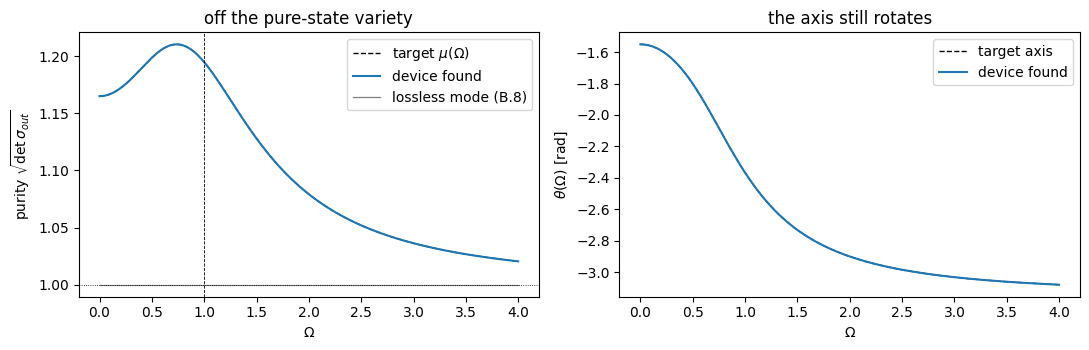

mu in [1.020, 1.210], most mixed at Omega = 0.74 (crossover 1.0); lossless mode: mu = 1


In [7]:
grid = np.linspace(0.0, 4.0, 201)
V_imp = np.array([np.real(optimizer_imp.oracle.covariance(info_imp["x"], w)) for w in grid])
target_imp = rotation_spectrum(grid, [0.5], decay_ratios=[np.sqrt(2.0)], losses=[loss])
lossless = rotation_spectrum(grid, [0.5], decay_ratios=[np.sqrt(2.0)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(grid, rotation_purity(target_imp), "k--", lw=1, label=r"target $\mu(\Omega)$")
axes[0].plot(grid, np.sqrt(np.linalg.det(V_imp)), label="device found")
axes[0].plot(grid, rotation_purity(lossless), color="grey", lw=0.9,
             label="lossless mode (B.8)")
axes[0].axhline(1.0, color="k", lw=0.6, ls=":")
axes[0].axvline(1.0, color="k", lw=0.6, ls="--")
axes[0].set_xlabel(r"$\Omega$"); axes[0].set_ylabel(r"purity $\sqrt{\det \sigma_{out}}$")
axes[0].set_title("off the pure-state variety"); axes[0].legend()

axes[1].plot(grid, squeeze_angle(target_imp), "k--", lw=1, label="target axis")
axes[1].plot(grid, squeeze_angle(V_imp), label="device found")
axes[1].set_xlabel(r"$\Omega$"); axes[1].set_ylabel(r"$\theta(\Omega)$ [rad]")
axes[1].set_title("the axis still rotates"); axes[1].legend()
plt.tight_layout(); plt.show()

purity = rotation_purity(target_imp)
print("mu in [%.3f, %.3f], most mixed at Omega = %.2f (crossover 1.0); lossless mode: mu = 1"
      % (purity.min(), purity.max(), grid[int(np.argmax(purity))]))
SUMMARY.append(("B.8-imp impure rotation", optimizer_imp.num_modes,
                "mu up to %.3f, gamma_0 = %.3f live" % (purity.max(), loss)))

**Careful with the "no lossless graph can do it" reading.** What is provable is the
*single-mode* statement: one lossless mode is all-pass, full stop. A **second** lossless mode
is not noiseless as far as the monitored port is concerned &mdash; it carries its own vacuum
input channel &mdash; so a two-mode lossless graph does fit the impure target. Impurity costs
*added noise*, and an auxiliary mode is one way to buy it. That is a mode-count statement, not
a no-lossless-graph statement.

In [8]:
_, success_aux, info_aux = fit(problem_imp, num_auxiliary_modes=1, intrinsic_losses=False)
print("lossless *two*-mode graph: %s, loss %.2e -- the aux mode's vacuum port supplies the noise"
      % ("VALID" if success_aux else "no witness", info_aux["loss_reached"]))

2 mode(s): VALID        loss = 9.84e-09   max Re eig(M~) = -0.8485
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)
   loss=9.84e-09   max Re eig(M~)=-0.8485
   cooperativities: C_{0,0}=+0.1138  C^{BS}_{0,1}=+0.0073  C^{SQZ}_{0,1}=+3.3200  C_{1,1}=+19.5122
   phases:          arg(nu_{0,0})=-1.1654  arg(g_{0,1})=-2.9094  arg(nu_{0,1})=+0.6227  arg(nu_{1,1})=-0.1932
   detunings:       Delta_0/kappa_0=+0.2330  Delta_1/kappa_1=-5.4754
   decay_ratios:    kappa~_0=+1.7535  kappa~_1=+99.6144
lossless *two*-mode graph: VALID, loss 9.84e-09 -- the aux mode's vacuum port supplies the noise


### B.8-nm &mdash; non-monotone rotation: a turning point costs the coupled partner

$\theta(\lvert\Omega\rvert)$ rises, turns over and comes back. One detuned mode cannot do it:
single-pole phase is monotone in $\lvert\Omega\rvert$ (swept over the whole single-mode family
below, not argued). The turning point needs the pole&ndash;zero interplay of **two coupled**
modes.

The trap this target exists to catch is a test that only counts modes: switching the coupling
off leaves the dynamical matrix block diagonal, so the second mode never reaches the monitored
port and the angle is *exactly* the one-mode angle. It is the hybridisation, not the mode
count, that buys the turn.

*(Sec. 8.7 phrases the requirement as "opposite-sign detunings". In this coupled-mode
parametrisation the sign of the bare detunings is not what decides it &mdash; a strongly
coupled same-sign pair hybridises into normal modes that straddle zero, and over a wide random
sweep the normal-mode sign rule predicts monotonicity only ~70% of the time. The default
reference below is a same-sign pair with $C^{BS} \gg$ the detunings.)*

In [9]:
problem_nm = non_monotone_rotation()
print(problem_nm.notes, "\n")

grid = np.linspace(0.0, 4.0, 201)
target_nm = rotation_spectrum(grid, (0.5, 0.5), coupling=1.0, decay_ratios=(1.0, 0.8))
uncoupled = rotation_spectrum(grid, (0.5, 0.5), coupling=0.0, decay_ratios=(1.0, 0.8))
one_mode = rotation_spectrum(grid, [0.5], decay_ratios=[1.0])
print("uncoupled pair == single mode to %.1e -- an idle partner is invisible to the port"
      % np.max(np.abs(uncoupled - one_mode)))

optimizer_nm, info_nm, modes_nm = mode_count_ladder(problem_nm, (0, 1))

B.8-nm  theta(|Omega|) turns over at Omega ~ 0.8 (sweep 1.83 rad out, 2.25 rad back); one mode is monotone, so this costs the coupled partner. 

uncoupled pair == single mode to 0.0e+00 -- an idle partner is invisible to the port


1 mode(s): no witness   loss = 1.26e+00   max Re eig(M~) = -0.7053


2 mode(s): VALID        loss = 9.65e-09   max Re eig(M~) = -0.4472
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)
   loss=9.65e-09   max Re eig(M~)=-0.4472
   cooperativities: C^{BS}_{0,1}=+3.9982  C^{SQZ}_{0,1}=+0.0000  C_{1,1}=+0.0000
   phases:          arg(g_{0,1})=-1.3689  arg(nu_{0,1})=-0.2347  arg(nu_{1,1})=-2.1359
   detunings:       Delta_0/kappa_0=+0.5011  Delta_1/kappa_1=+0.4987
   decay_ratios:    kappa~_0=+0.9989  kappa~_1=+0.8011


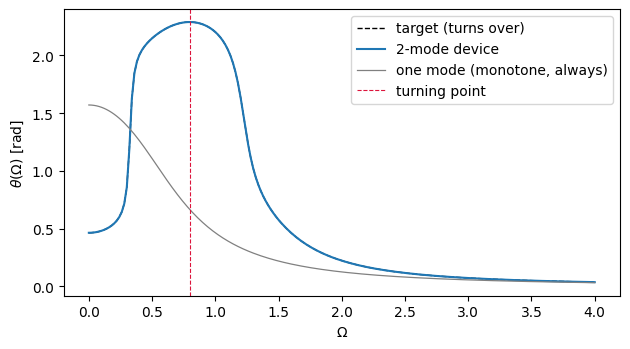

turning point at Omega = 0.80: 1.83 rad out, 2.25 rad back
hybridisation found: C^BS_{0,1} = 3.998 against detunings 0.501, 0.499


In [10]:
theta_target = squeeze_angle(target_nm)
V_nm = np.array([np.real(optimizer_nm.oracle.covariance(info_nm["x"], w)) for w in grid])

plt.figure(figsize=(6.4, 3.6))
plt.plot(grid, theta_target, "k--", lw=1, label="target (turns over)")
plt.plot(grid, squeeze_angle(V_nm), label="%i-mode device" % modes_nm)
plt.plot(grid, squeeze_angle(one_mode), color="grey", lw=0.9,
         label="one mode (monotone, always)")
turn = grid[int(np.argmax(theta_target))]
plt.axvline(turn, color="crimson", lw=0.8, ls="--", label=r"turning point")
plt.xlabel(r"$\Omega$"); plt.ylabel(r"$\theta(\Omega)$ [rad]")
plt.legend(); plt.tight_layout(); plt.show()

print("turning point at Omega = %.2f: %.2f rad out, %.2f rad back"
      % (turn, theta_target.max() - theta_target[0], theta_target.max() - theta_target[-1]))
print("hybridisation found: C^BS_{0,1} = %.3f against detunings %s"
      % (info_nm["parameters"]["cooperativities"]["C^{BS}_{0,1}"],
         ", ".join("%.3f" % v for v in info_nm["parameters"]["detunings"].values())))
SUMMARY.append(("B.8-nm turning point", modes_nm,
                "theta turns at Omega = %.2f" % turn))

### B.8-wind &mdash; prescribed total rotation: winding as a counted resource

Demand more accumulated sweep $\sum \lvert\Delta\theta\rvert$ across the band than the minimal
graph can pack into it, and the winding itself forces another mode.

**Do not read $\pi/2$ as the single-mode budget.** The $\pi/2$ of B.8 is that device's *useful
in-band* rotation, not its ceiling: scanning the whole single-mode family
(`single_mode_winding_ceiling`) gives $\approx \pi$ &mdash; one pole turns the sideband phase
by $\pi$, approached only asymptotically across a finite band. So the winding that actually
forces the second mode is band- and parameter-dependent and is **measured**, never
hard-coded.

In [11]:
omega_max = 6.0
dense = np.linspace(0.0, omega_max, 241)
ceiling = single_mode_winding_ceiling(omega_max=omega_max, num_points=121)
print("single-mode winding ceiling on [0, %.0f]: %.3f rad  (pi = %.3f, pi/2 = %.3f)"
      % (omega_max, ceiling, np.pi, 0.5 * np.pi))

print("\nsweeping the demanded winding *inside* the single-mode family:")
for detuning, ratio in ((0.5, 1.4), (2.0, 0.7), (5.0, 0.5)):
    prob = winding_rotation(detunings=(detuning,), coupling=0.0, decay_ratios=(ratio,))
    wind = accumulated_rotation(squeeze_angle(
        rotation_spectrum(dense, (detuning,), decay_ratios=(ratio,))))
    _, ok, _ = fit(prob, num_auxiliary_modes=0)
    print("   Delta/kappa = %.1f, kappa~ = %.1f -> winding %.3f rad (%s)"
          % (detuning, ratio, wind, "one mode is enough" if ok else "one mode fails"))

single-mode winding ceiling on [0, 6]: 3.013 rad  (pi = 3.142, pi/2 = 1.571)

sweeping the demanded winding *inside* the single-mode family:


1 mode(s): VALID        loss = 3.73e-12   max Re eig(M~) = -0.7000
   graph: detuning Delta_0
   loss=3.73e-12   max Re eig(M~)=-0.7000
   detunings:       Delta_0/kappa_0=+0.5000
   decay_ratios:    kappa~_0=+1.4000
   Delta/kappa = 0.5, kappa~ = 1.4 -> winding 1.544 rad (one mode is enough)


1 mode(s): VALID        loss = 1.39e-11   max Re eig(M~) = -0.3500
   graph: detuning Delta_0
   loss=1.39e-11   max Re eig(M~)=-0.3500
   detunings:       Delta_0/kappa_0=+2.0000
   decay_ratios:    kappa~_0=+0.7000
   Delta/kappa = 2.0, kappa~ = 0.7 -> winding 2.623 rad (one mode is enough)


1 mode(s): VALID        loss = 1.59e-09   max Re eig(M~) = -0.2500
   graph: detuning Delta_0
   loss=1.59e-09   max Re eig(M~)=-0.2500
   cooperativities: C_{0,0}=+0.0000
   phases:          arg(nu_{0,0})=-0.2324
   detunings:       Delta_0/kappa_0=+4.9999
   decay_ratios:    kappa~_0=+0.5000
   Delta/kappa = 5.0, kappa~ = 0.5 -> winding 2.900 rad (one mode is enough)


B.8-wind  accumulated sweep 3.6 rad over |Omega| <= 6 -- past the ~pi ceiling of a single mode, so the winding itself costs the second one. 

target winding 3.603 rad > ceiling 3.013 rad -> provably not a single mode



1 mode(s): no witness   loss = 1.37e+00   max Re eig(M~) = -0.7234


2 mode(s): VALID        loss = 7.53e-09   max Re eig(M~) = -0.3922
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, on-site squeezing 1 (complex)
   loss=7.53e-09   max Re eig(M~)=-0.3922
   cooperativities: C^{BS}_{0,1}=+1.4400  C^{SQZ}_{0,1}=+0.0000  C_{1,1}=+0.0000
   phases:          arg(g_{0,1})=+0.8758  arg(nu_{0,1})=-1.3194  arg(nu_{1,1})=+1.0997
   detunings:       Delta_0/kappa_0=+1.0000  Delta_1/kappa_1=+1.5000
   decay_ratios:    kappa~_0=+0.9000  kappa~_1=+0.7000


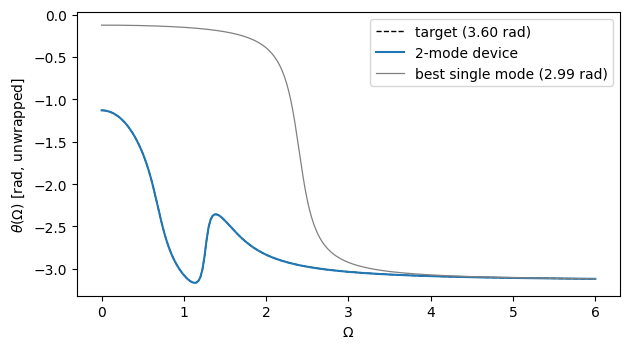

In [12]:
problem_wind = winding_rotation()
print(problem_wind.notes, "\n")
target_wind = rotation_spectrum(dense, (1.0, 1.5), coupling=0.6, decay_ratios=(0.9, 0.7))
winding = accumulated_rotation(squeeze_angle(target_wind))
print("target winding %.3f rad > ceiling %.3f rad -> provably not a single mode\n"
      % (winding, ceiling))

optimizer_wind, info_wind, modes_wind = mode_count_ladder(problem_wind, (0, 1))

V_wind = np.array([np.real(optimizer_wind.oracle.covariance(info_wind["x"], w)) for w in dense])
best_single = max(((accumulated_rotation(squeeze_angle(
    rotation_spectrum(dense, (d,), decay_ratios=(k,)))), d, k)
    for d in (1.0, 2.0, 4.0, 8.0) for k in (0.3, 0.5, 1.0)), key=lambda t: t[0])

plt.figure(figsize=(6.4, 3.6))
plt.plot(dense, squeeze_angle(target_wind), "k--", lw=1,
         label="target (%.2f rad)" % winding)
plt.plot(dense, squeeze_angle(V_wind), label="%i-mode device" % modes_wind)
plt.plot(dense, squeeze_angle(rotation_spectrum(dense, (best_single[1],),
                                                decay_ratios=(best_single[2],))),
         color="grey", lw=0.9, label="best single mode (%.2f rad)" % best_single[0])
plt.xlabel(r"$\Omega$"); plt.ylabel(r"$\theta(\Omega)$ [rad, unwrapped]")
plt.legend(); plt.tight_layout(); plt.show()
SUMMARY.append(("B.8-wind winding", modes_wind,
                "%.2f rad demanded vs %.2f rad ceiling" % (winding, ceiling)))

**Winding is a *sufficient* obstruction, not a necessary one.** Winding past the ceiling
proves a second mode is needed; the converse is false, and it is worth checking so nobody turns
the ceiling into a budget. Scale the same reference down until it winds only ~1.2 rad, far
under the ceiling &mdash; and it still does not fit on one mode, because its *shape* is what
one pole cannot make.

In [13]:
scale = 0.4
small = (1.0 * scale, 1.5 * scale)
problem_small = winding_rotation(detunings=small, coupling=0.6 * scale)
wind_small = accumulated_rotation(squeeze_angle(
    rotation_spectrum(dense, small, coupling=0.6 * scale, decay_ratios=(0.9, 0.7))))
_, ok_small, info_small = fit(problem_small, num_auxiliary_modes=0)
print("winding %.3f rad (< ceiling %.3f) and still %s on one mode, best loss %.2e"
      % (wind_small, ceiling, "VALID" if ok_small else "no witness",
         info_small["loss_reached"]))

1 mode(s): no witness   loss = 6.10e-02   max Re eig(M~) = -0.5613
winding 1.200 rad (< ceiling 3.013) and still no witness on one mode, best loss 6.10e-02


### The rotation family &mdash; the full Sec. 6 search (slow: ~10 min in total)

Everything above is the **oracle** on the fully connected graph: it says *this many modes can
do it*. The discovery loop is the breadth-first walk down the graph lattice (Sec. 6), which
returns the two libraries and the *irreducible* graphs &mdash; the sharper statement.

B.8-imp's lattice is B.8's (1 mode, 2 slots, seconds). B.8-nm and B.8-wind live on the 2-mode
lattice, $3^6 = 729$ graphs at ~1 s per oracle call, so those two take ~3 and ~6 minutes.

In [14]:
optimizer_imp_search, irreducibles_imp = search(problem_imp, num_auxiliary_modes=0)
print()
print(optimizer_imp_search.completeness_statement().splitlines()[0])

lattice: 1 modes, 2 slots, max complexity 3
start breadth-first search over 2 slots (max complexity 3)
test 1 graphs with 3 degrees of freedom:


test 1 graphs with 2 degrees of freedom:


test 1 graphs with 1 degrees of freedom:
test 1 graphs with 0 degrees of freedom:
valid: 2    invalid: 3 (certified 0, uncertified 3)    oracle calls: 52    escalations: 2
optimisation finished, list of irreducible graphs has 1 elements (3 uncertified rejections)

1 irreducible graph(s), 4 top-level oracle calls, 0.6 s
   complexity 1:  detuning Delta_0   [loss 1.34e-09, alpha -0.849]

1 valid graph(s), with the converged parameters:

#0  complexity=1  couplings=0  pumps=0
      detuning Delta_0
      loss=1.34e-09   max Re eig(M~)=-0.8485
      detunings:
         Delta_0/kappa_0      +0.5000
      intrinsic_losses:
         gamma_0              +0.2000
      decay_ratios:
         kappa~_0             +1.4142

libraries: valid 2 | invalid 3  (certified 0, uncertified 3)

The list of irreducible graphs is complete up to at most 3 false negatives (graphs rejected without a certificate):


In [15]:
optimizer_nm_search, irreducibles_nm = search(problem_nm, num_auxiliary_modes=1)
print()
print(optimizer_nm_search.completeness_statement().splitlines()[0])

lattice: 2 modes, 6 slots, max complexity 10
start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 5 graphs with 9 degrees of freedom:


test 12 graphs with 8 degrees of freedom:


test 27 graphs with 7 degrees of freedom:


test 48 graphs with 6 degrees of freedom:


...

test 57 graphs with 4 degrees of freedom:


test 39 graphs with 3 degrees of freedom:


test 19 graphs with 2 degrees of freedom:


test 6 graphs with 1 degrees of freedom:


test 1 graphs with 0 degrees of freedom:
valid: 8    invalid: 270 (certified 0, uncertified 270)    oracle calls: 5412    escalations: 269
optimisation finished, list of irreducible graphs has 1 elements (270 uncertified rejections)

1 irreducible graph(s), 274 top-level oracle calls, 210.8 s
   complexity 3:  detuning Delta_0, beam-splitter 0-1 (real), detuning Delta_1   [loss 4.95e-10, alpha -0.447]

1 valid graph(s), with the converged parameters:

#0  complexity=3  couplings=1  pumps=0
      detuning Delta_0
      beam-splitter 0-1 (real)
      detuning Delta_1
      loss=4.95e-10   max Re eig(M~)=-0.4472
      cooperativities:
         C^{BS}_{0,1}         +4.0000
      phases:
         arg(g_{0,1})         +3.1416
      detunings:
         Delta_0/kappa_0      +0.5000
         Delta_1/kappa_1      +0.5000
      decay_ratios:
         kappa~_0             +1.0000
         kappa~_1             +0.8000

libraries: valid 8 | invalid 270  (certified 0, uncertified 270)

The list of ir

In [16]:
optimizer_wind_search, irreducibles_wind = search(problem_wind, num_auxiliary_modes=1)
print()
print(optimizer_wind_search.completeness_statement().splitlines()[0])

lattice: 2 modes, 6 slots, max complexity 10
start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 4 graphs with 9 degrees of freedom:


test 14 graphs with 8 degrees of freedom:


test 27 graphs with 7 degrees of freedom:


test 48 graphs with 6 degrees of freedom:


...

test 57 graphs with 4 degrees of freedom:


test 39 graphs with 3 degrees of freedom:


test 19 graphs with 2 degrees of freedom:


test 6 graphs with 1 degrees of freedom:


test 1 graphs with 0 degrees of freedom:
valid: 6    invalid: 271 (certified 0, uncertified 271)    oracle calls: 5436    escalations: 271
optimisation finished, list of irreducible graphs has 1 elements (271 uncertified rejections)

1 irreducible graph(s), 274 top-level oracle calls, 213.3 s
   complexity 3:  detuning Delta_0, beam-splitter 0-1 (real), detuning Delta_1   [loss 3.77e-10, alpha -0.392]

1 valid graph(s), with the converged parameters:

#0  complexity=3  couplings=1  pumps=0
      detuning Delta_0
      beam-splitter 0-1 (real)
      detuning Delta_1
      loss=3.77e-10   max Re eig(M~)=-0.3922
      cooperativities:
         C^{BS}_{0,1}         +1.4400
      phases:
         arg(g_{0,1})         +3.1416
      detunings:
         Delta_0/kappa_0      +1.0000
         Delta_1/kappa_1      +1.5000
      decay_ratios:
         kappa~_0             +0.9000
         kappa~_1             +0.7000

libraries: valid 6 | invalid 271  (certified 0, uncertified 271)

The list of ir

Three things the search says that the oracle could not.

**No squeezing element anywhere.** All three minimal devices are purely passive &mdash;
detunings and one real beam-splitter. The squeezing is entirely in the declared input; the graph
only rotates it, and for B.8-imp dilutes it. Same result as B.8, now for the whole family.

**B.8-imp's minimal graph is complexity 1**, a bare detuned mode. The impurity is not a graph
element at all: $\gamma_i$ is a continuous parameter of every mode, so buying added noise costs
*zero* graph complexity &mdash; it only requires the loss to be **live**. Freeze the losses and
the same lattice has no valid graph at all.

**B.8-nm and B.8-wind land on the identical minimal graph** (complexity 3, `detuning
`$\Delta_0$` + beam-splitter 0-1 (real) + detuning `$\Delta_1$). A turning point and an excess
winding are different demands on the *parameters* of the same two-mode passive filter: the
shape/magnitude cost is one extra mode plus its coupling, not a different topology.

As everywhere in this package, no certificate fires on a spectral target (`sos_no_hurwitz` is a
stub and the fit-range SDP rarely fires on a grid), so each list is complete only up to its
`n_uncertified` count &mdash; the completeness caveat printed above, not a blemish to hide.

## B.9 &mdash; bandpass sideband squeezing

A Lorentzian squeezing window: position $\Omega_c \leftarrow$ detuning, width
$B \leftarrow \tilde\kappa$, depth $\leftarrow$ squeezing cooperativity. One resonance cannot
set all three independently, so the single-mode fit stalls around $5\times10^{-4}$ and the
second mode is what makes the target reachable.

1 mode(s): no witness   loss = 4.69e-04   max Re eig(M~) = -0.3709


2 mode(s): VALID        loss = 9.87e-09   max Re eig(M~) = -0.2196
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)
   loss=9.87e-09   max Re eig(M~)=-0.2196
   cooperativities: C_{0,0}=+32.5175  C^{BS}_{0,1}=+6.6733  C^{SQZ}_{0,1}=+6.6648  C_{1,1}=+31.4104
   phases:          arg(nu_{0,0})=-3.1147  arg(g_{0,1})=-2.9545  arg(nu_{0,1})=-3.0940  arg(nu_{1,1})=-0.3397
   detunings:       Delta_0/kappa_0=+3.1043  Delta_1/kappa_1=-2.7725
   decay_ratios:    kappa~_0=+0.8339  kappa~_1=+1.5631


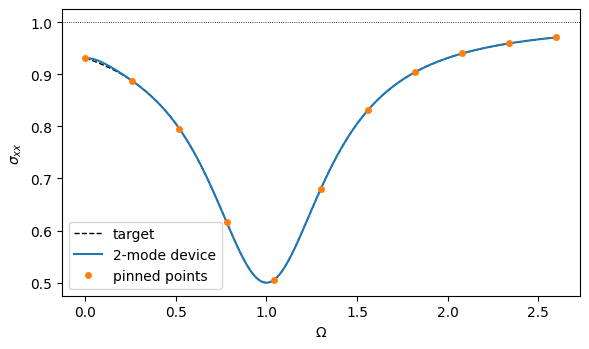

dip centre 1.000 (asked 1.000), depth 0.500 (asked 0.500), half-width 0.395 (asked 0.400)


In [17]:
depth, center, bandwidth = 0.5, 1.0, 0.4
problem_b9 = bandpass_squeezer(depth=depth, center=center, bandwidth=bandwidth)
optimizer_b9, info_b9, modes_b9 = mode_count_ladder(problem_b9, (0, 1))

grid = np.linspace(0.0, center + 4 * bandwidth, 261)
achieved = spectrum_of(optimizer_b9, info_b9["x"], grid)
half = 0.5 * (1.0 + depth)
inside = grid[achieved < half]

plt.figure(figsize=(6, 3.6))
plt.plot(grid, lorentzian_dip(grid, depth, center, bandwidth), "k--", lw=1, label="target")
plt.plot(grid, achieved, label="%i-mode device" % modes_b9)
plt.plot(problem_b9.target.omegas,
         spectrum_of(optimizer_b9, info_b9["x"], problem_b9.target.omegas), "o", ms=4,
         label="pinned points")
plt.axhline(1.0, color="k", lw=0.6, ls=":")
plt.xlabel(r"$\Omega$"); plt.ylabel(r"$\sigma_{xx}$"); plt.legend(); plt.tight_layout(); plt.show()

print("dip centre %.3f (asked %.3f), depth %.3f (asked %.3f), half-width %.3f (asked %.3f)"
      % (grid[int(np.argmin(achieved))], center, achieved.min(), depth,
         0.5 * (inside.max() - inside.min()), bandwidth))
SUMMARY.append(("B.9 bandpass squeezing", modes_b9,
                "dip %.3f at %.2f, HWHM %.2f" % (achieved.min(), center, bandwidth)))

### B.9 &mdash; the full Sec. 6 search (slow: ~8 minutes)

Two modes means 6 slots and a lattice of $3^6 = 729$ graphs, and every oracle call on a
9-point grid target costs ~1 s (versus ~10 ms for the single-point targets of notebooks 1&ndash;4).
That factor is the whole cost story of spectral discovery.

The result is worth the wait: **every** irreducible graph carries *two* squeezing elements
(on-site + on-site, or on-site + two-mode) plus a detuning or a beam-splitter. The claim "one
resonance cannot make this window" stops being an observation about a stalled fit and becomes a
structural statement about the lattice.

Note the completeness line. Almost every rejection here is `certified=False`: with
`sos_no_hurwitz` stubbed and the fit-range SDP rarely firing on a grid target, a spectral
target produces far more uncertified invalids than a single-point one. That count *is* the
strength of the claim (Sec. 8) &mdash; it is not noise to be hidden.

In [18]:
optimizer_b9_search, irreducibles_b9 = search(problem_b9, num_auxiliary_modes=1)
print()
print(optimizer_b9_search.completeness_statement().splitlines()[0])

lattice: 2 modes, 6 slots, max complexity 10
start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 6 graphs with 9 degrees of freedom:


test 19 graphs with 8 degrees of freedom:


test 40 graphs with 7 degrees of freedom:


test 61 graphs with 6 degrees of freedom:


test 70 graphs with 5 degrees of freedom:


test 61 graphs with 4 degrees of freedom:


      certificate fired: passive_range
test 37 graphs with 3 degrees of freedom:


test 15 graphs with 2 degrees of freedom:


test 3 graphs with 1 degrees of freedom:
valid: 43    invalid: 270 (certified 1, uncertified 269)    oracle calls: 5621    escalations: 275
optimisation finished, list of irreducible graphs has 11 elements (269 uncertified rejections)

11 irreducible graph(s), 313 top-level oracle calls, 448.9 s
   complexity 6:  beam-splitter 0-1 (real), on-site squeezing 0 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)   [loss 9.99e-09, alpha -0.209]
   complexity 6:  beam-splitter 0-1 (real), on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), on-site squeezing 1 (real)   [loss 9.77e-09, alpha -0.209]
   complexity 7:  beam-splitter 0-1 (complex), detuning Delta_1, on-site squeezing 0 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (real)   [loss 9.79e-09, alpha -0.223]
   complexity 6:  detuning Delta_0, on-site squeezing 0 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)   [loss 1.00e-08, alpha -0.210]
   complexity 6:  det

## B.10 &mdash; flat-top plateau: the spectral degree &rarr; mode count bound at work

An order-$n$ Butterworth plateau makes the first $2n-1$ $\Omega$-derivatives vanish at
$\Omega = 0$ (so App. B.4's derivative pins are its low-order shadow), then rolls sharply to
vacuum. Prescribing a sharper band edge raises the McMillan degree of the target spectrum, and
the degree is paid for in **modes** &mdash; each new mode brings its own $\tilde\kappa_i$.

In [19]:
orders = (1, 2, 3)
ladder = {}
fits = {}
for order in orders:
    print("order n = %i" % order)
    problem = flat_top_squeezer(order=order)
    winner = mode_count_ladder(problem, (0, 1))
    ladder[order] = None if winner is None else winner[2]
    fits[order] = winner
    print()

print("order n   minimum modes found")
for order in orders:
    print("%7i   %s" % (order, ladder[order] if ladder[order] else "> 2"))

order n = 1


1 mode(s): VALID        loss = 7.74e-09   max Re eig(M~) = -0.6995
   graph: detuning Delta_0, on-site squeezing 0 (complex)
   loss=7.74e-09   max Re eig(M~)=-0.6995
   cooperativities: C_{0,0}=+0.0313
   phases:          arg(nu_{0,0})=-1.7707
   detunings:       Delta_0/kappa_0=+0.0086
   decay_ratios:    kappa~_0=+1.6979


2 mode(s): VALID        loss = 2.07e-09   max Re eig(M~) = -0.0370
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)
   loss=2.07e-09   max Re eig(M~)=-0.0370
   cooperativities: C_{0,0}=+0.0206  C^{BS}_{0,1}=+5.1568  C^{SQZ}_{0,1}=+2.6872  C_{1,1}=+12.6946
   phases:          arg(nu_{0,0})=-1.4743  arg(g_{0,1})=+1.1880  arg(nu_{0,1})=-2.2418  arg(nu_{1,1})=+0.0857
   detunings:       Delta_0/kappa_0=-0.0099  Delta_1/kappa_1=+1.2485
   decay_ratios:    kappa~_0=+1.8702  kappa~_1=+0.0539

order n = 2


1 mode(s): VALID        loss = 2.08e-10   max Re eig(M~) = -0.7071
   graph: detuning Delta_0, on-site squeezing 0 (real)
   loss=2.08e-10   max Re eig(M~)=-0.7071
   cooperativities: C_{0,0}=+0.1250
   phases:          arg(nu_{0,0})=+3.1416
   detunings:       Delta_0/kappa_0=+0.5303
   decay_ratios:    kappa~_0=+1.4142


2 mode(s): VALID        loss = 8.73e-09   max Re eig(M~) = -0.5719
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, on-site squeezing 0 (real), two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)
   loss=8.73e-09   max Re eig(M~)=-0.5719
   cooperativities: C_{0,0}=+0.7472  C^{BS}_{0,1}=+89.0981  C^{SQZ}_{0,1}=+53.0669  C_{1,1}=+35.3585
   phases:          arg(nu_{0,0})=+0.0002  arg(g_{0,1})=+1.1924  arg(nu_{0,1})=-1.1786  arg(nu_{1,1})=-0.4437
   detunings:       Delta_0/kappa_0=-0.4350  Delta_1/kappa_1=-1.3434
   decay_ratios:    kappa~_0=+2.5322  kappa~_1=+0.0338

order n = 3


1 mode(s): no witness   loss = 2.10e-04   max Re eig(M~) = -0.5849


2 mode(s): VALID        loss = 1.75e-09   max Re eig(M~) = -0.3477
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)
   loss=1.75e-09   max Re eig(M~)=-0.3477
   cooperativities: C_{0,0}=+0.0000  C^{BS}_{0,1}=+4.8056  C^{SQZ}_{0,1}=+3.0550  C_{1,1}=+2.4952
   phases:          arg(nu_{0,0})=+1.9386  arg(g_{0,1})=-1.4142  arg(nu_{0,1})=+1.8277  arg(nu_{1,1})=-1.6189
   detunings:       Delta_0/kappa_0=-0.0941  Delta_1/kappa_1=-0.6738
   decay_ratios:    kappa~_0=+0.8092  kappa~_1=+1.5412

order n   minimum modes found
      1   1
      2   1
      3   2


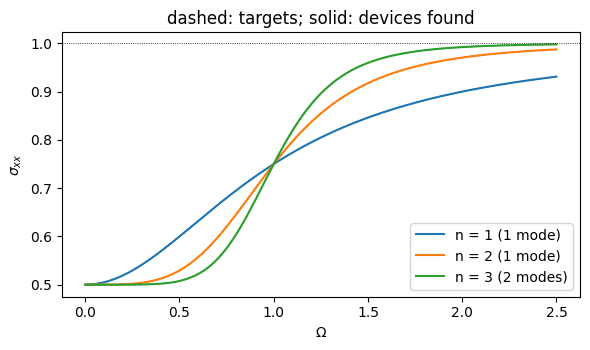

In [20]:
grid = np.linspace(0.0, 2.5, 201)
plt.figure(figsize=(6, 3.6))
for order in orders:
    optimizer, info, num_modes = fits[order]
    plt.plot(grid, butterworth_dip(grid, order=order), "k--", lw=0.8)
    plt.plot(grid, spectrum_of(optimizer, info["x"], grid),
             label="n = %i (%i mode%s)" % (order, num_modes, "s" if num_modes > 1 else ""))
plt.axhline(1.0, color="k", lw=0.6, ls=":")
plt.xlabel(r"$\Omega$"); plt.ylabel(r"$\sigma_{xx}$")
plt.title("dashed: targets; solid: devices found")
plt.legend(); plt.tight_layout(); plt.show()
SUMMARY.append(("B.10 flat-top plateau", ladder[3],
                "orders %s -> modes %s" % (list(orders), [ladder[o] for o in orders])))

### B.10 &mdash; the full Sec. 6 search, order 2 vs order 3 (slow: ~8 minutes)

The mode-count ladder above compares *fully connected* graphs. The search compares **minimal**
ones, which is the sharper form of the degree bound: run it at order 2 (a 1-mode lattice,
seconds) and at order 3 (a 2-mode lattice, ~8 minutes) and read off what the extra order of
band edge actually bought.

In [21]:
problem_b10_n2 = flat_top_squeezer(order=2)
optimizer_b10_n2, irreducibles_b10_n2 = search(problem_b10_n2, num_auxiliary_modes=0)
print()
print(optimizer_b10_n2.completeness_statement().splitlines()[0])

lattice: 1 modes, 2 slots, max complexity 3
start breadth-first search over 2 slots (max complexity 3)
test 1 graphs with 3 degrees of freedom:


test 1 graphs with 2 degrees of freedom:


test 2 graphs with 1 degrees of freedom:
      certificate fired: passive_range
valid: 2    invalid: 3 (certified 1, uncertified 2)    oracle calls: 53    escalations: 3
optimisation finished, list of irreducible graphs has 1 elements (2 uncertified rejections)

1 irreducible graph(s), 4 top-level oracle calls, 0.8 s
   complexity 2:  detuning Delta_0, on-site squeezing 0 (real)   [loss 2.08e-10, alpha -0.707]

1 valid graph(s), with the converged parameters:

#0  complexity=2  couplings=1  pumps=1
      detuning Delta_0
      on-site squeezing 0 (real)
      loss=2.08e-10   max Re eig(M~)=-0.7071
      cooperativities:
         C_{0,0}              +0.1250
      phases:
         arg(nu_{0,0})        +3.1416
      detunings:
         Delta_0/kappa_0      +0.5303
      decay_ratios:
         kappa~_0             +1.4142

libraries: valid 2 | invalid 3  (certified 1, uncertified 2)

The list of irreducible graphs is complete up to at most 2 false negatives (graphs rejected without a cert

In [22]:
problem_b10_n3 = flat_top_squeezer(order=3)
optimizer_b10_n3, irreducibles_b10_n3 = search(problem_b10_n3, num_auxiliary_modes=1)
print()
print(optimizer_b10_n3.completeness_statement().splitlines()[0])

lattice: 2 modes, 6 slots, max complexity 10
start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 5 graphs with 9 degrees of freedom:


test 18 graphs with 8 degrees of freedom:


test 40 graphs with 7 degrees of freedom:


test 61 graphs with 6 degrees of freedom:


test 69 graphs with 5 degrees of freedom:


test 60 graphs with 4 degrees of freedom:


      certificate fired: passive_range
test 37 graphs with 3 degrees of freedom:


test 15 graphs with 2 degrees of freedom:


test 3 graphs with 1 degrees of freedom:
valid: 147    invalid: 161 (certified 1, uncertified 160)    oracle calls: 3829    escalations: 169
optimisation finished, list of irreducible graphs has 20 elements (160 uncertified rejections)

20 irreducible graph(s), 305 top-level oracle calls, 291.2 s
   complexity 5:  beam-splitter 0-1 (real), two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)   [loss 9.89e-09, alpha -0.500]
   complexity 5:  beam-splitter 0-1 (real), on-site squeezing 0 (real), two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)   [loss 7.37e-09, alpha -0.184]
   complexity 5:  beam-splitter 0-1 (real), on-site squeezing 0 (real), two-mode squeezing 0-1 (complex), on-site squeezing 1 (real)   [loss 6.77e-09, alpha -0.281]
   complexity 5:  beam-splitter 0-1 (real), on-site squeezing 0 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (real)   [loss 9.69e-09, alpha -0.500]
   complexity 5:  beam-splitter 0-1 (real), detuning Delta_1, two-m

In [23]:
print("order 2, minimal devices on a 1-mode lattice:")
for graph in irreducibles_b10_n2:
    print("   complexity %i:  %s"
          % (int(np.sum(graph)), ", ".join(optimizer_b10_n2.space.describe(graph))))
print("\norder 3, minimal devices on a 2-mode lattice: %i of them, cheapest"
      % len(irreducibles_b10_n3))
cheapest = sorted(irreducibles_b10_n3, key=lambda g: int(np.sum(g)))[:5]
for graph in cheapest:
    print("   complexity %i:  %s"
          % (int(np.sum(graph)), ", ".join(optimizer_b10_n3.space.describe(graph))))
print("\nThe band-edge order is paid for in modes, and the search says so in the only")
print("currency that matters: the *minimal* graph that realises the target.")

order 2, minimal devices on a 1-mode lattice:
   complexity 2:  detuning Delta_0, on-site squeezing 0 (real)

order 3, minimal devices on a 2-mode lattice: 20 of them, cheapest
   complexity 4:  beam-splitter 0-1 (real), detuning Delta_1, on-site squeezing 0 (real), on-site squeezing 1 (real)
   complexity 4:  detuning Delta_0, on-site squeezing 0 (real), two-mode squeezing 0-1 (real), on-site squeezing 1 (real)
   complexity 4:  detuning Delta_0, detuning Delta_1, on-site squeezing 0 (real), two-mode squeezing 0-1 (real)
   complexity 4:  detuning Delta_0, beam-splitter 0-1 (real), on-site squeezing 0 (real), on-site squeezing 1 (real)
   complexity 4:  detuning Delta_0, beam-splitter 0-1 (real), on-site squeezing 0 (real), two-mode squeezing 0-1 (real)

The band-edge order is paid for in modes, and the search says so in the only
currency that matters: the *minimal* graph that realises the target.


### B.10 order 3 &mdash; devices vs *limit points* (a cooperativity budget)

The ranked list above hides a trap.  The cheapest order-3 architectures do not
realise the target at finite parameters at all: they only approach it along a ray
that runs to infinity, and the search calls them VALID because the fit crosses the
(loosened) tolerance somewhere along that ray.

Refit the cheapest device while tightening the tolerance.  A genuine solution keeps
its parameters and drops its loss; a limit point walks further out instead.


In [24]:
def build_named(problem, elements, c_max=None, tolerance=1e-8,
                num_auxiliary_modes=1, num_tests=NUM_TESTS):
    """Optimizer + graph for one named architecture, optionally under a budget."""
    kwargs = problem.optimizer_kwargs(kwargs_optimization={
        "num_tests": num_tests, "max_violation_success": tolerance})
    if c_max is not None:
        kwargs["constraints"] = tuple(kwargs.get("constraints", ())) + (
            CooperativityBudget(c_max),)
    optimizer = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=SEED,
        make_initial_test=False, **kwargs)
    graph = optimizer.space.empty()
    for kind, i, j, value in elements:
        graph[optimizer.space.slots.index((kind, i, j))] = value
    return optimizer, graph


def fit_named(problem, elements, c_max=None, tolerance=1e-8, num_tests=NUM_TESTS):
    optimizer, graph = build_named(problem, elements, c_max, tolerance,
                                   num_tests=num_tests)
    success, infos = optimizer.test_graph(graph)
    best = next((i for i in infos if i["success"]),
                min(infos, key=lambda i: i["loss_reached"]))
    return optimizer, graph, success, best


# the cheapest order-3 device of the ranked list, and a richer one on the same lattice
CHEAPEST_N3 = [("beamsplitter", 0, 1, 1), ("detuning", 1, 1, 1),
               ("onsite_squeezing", 0, 0, 1), ("onsite_squeezing", 1, 1, 1)]
RICHER_N3 = [("detuning", 0, 0, 1), ("beamsplitter", 0, 1, 2), ("detuning", 1, 1, 1),
             ("two_mode_squeezing", 0, 1, 2), ("onsite_squeezing", 1, 1, 2)]

print("cheapest device, refitted at three tolerances:")
print("tolerance   loss        C_00        C_11      Delta_1   C_11/Delta^2")
for tol in (1e-8, 1e-9, 1e-10):
    _, _, _, best = fit_named(problem_b10_n3, CHEAPEST_N3, tolerance=tol, num_tests=30)
    c = best["parameters"]["cooperativities"]
    delta = abs(best["parameters"]["detunings"]["Delta_1/kappa_1"])
    print("%.0e    %.2e   %.3e   %8.1f   %7.2f   %7.2f"
          % (tol, best["loss_reached"], c["C_{0,0}"], c["C_{1,1}"], delta,
             c["C_{1,1}"] / delta ** 2))


cheapest device, refitted at three tolerances:
tolerance   loss        C_00        C_11      Delta_1   C_11/Delta^2


1e-08    9.99e-09   2.011e-04      518.5     11.44      3.96


1e-09    9.95e-10   9.258e-05     1153.1     17.02      3.98


1e-10    5.83e-10   7.666e-05     1372.9     18.56      3.99


`C_11` and `Delta_1` diverge together while `C_11/Delta_1^2 -> 4`, i.e.
$|\nu_{11}| \to \Delta_1$: the auxiliary mode is a far-detuned degenerate parametric
amplifier held at its detuned threshold, and the on-site squeezer on the port shrinks
as $1/\Delta_1^2$ while staying necessary (deleting it stalls the fit at $2.8\times10^{-6}$).
That is the same *kind* of object as B.2&prime;'s bus mode &mdash; a limit point &mdash; except that
here nothing forces it: no hardware restriction is in play.

Tightening the tolerance is therefore not a fix; it just walks further along the ray.
The knob that *is* diverging is the pump strength, so bound that instead:
`CooperativityBudget(c_max)` is a one-sided hinge $4|H_{ij}|^2 \le C_\mathrm{max}$ &mdash; the
statement that pumps carry finite power.  A limit point fails at **every** finite budget,
and its loss degrades as the budget tightens; a genuine device is indifferent.

In [25]:
print("%-22s %-10s %-9s %-11s %s"
      % ("architecture", "budget", "verdict", "loss", "max C"))
for label, elements in (("cheapest (limit pt)", CHEAPEST_N3),
                        ("richer device", RICHER_N3)):
    for c_max in (None, 100.0, 25.0):
        optimizer, graph, success, best = fit_named(
            problem_b10_n3, elements, c_max=c_max, num_tests=30)
        coop = best["parameters"]["cooperativities"]
        print("%-22s %-10s %-9s %.2e    %.1f"
              % (label, "none" if c_max is None else "C<=%g" % c_max,
                 "VALID" if success else "INVALID", best["loss_reached"],
                 max(coop.values()) if coop else 0.0))


architecture           budget     verdict   loss        max C


cheapest (limit pt)    none       VALID     9.99e-09    518.5


cheapest (limit pt)    C<=100     INVALID   2.94e-07    94.2


cheapest (limit pt)    C<=25      INVALID   2.20e-06    17.8


richer device          none       VALID     8.46e-09    22.4


richer device          C<=100     VALID     4.73e-09    3.7


richer device          C<=25      VALID     9.99e-09    19.4


The richer architecture &mdash; two detunings, a *complex* beam-splitter, a
two-mode squeezing edge and on-site squeezing on the auxiliary mode &mdash; meets the same
order-3 plateau at bounded pump strength.  It costs more (complexity 8, three pumps
against the limit point's four and two), which is exactly why the cost ranking buries it.

Its optimised parameters under the budget, and its spectrum against the target:

VALID under C <= 100
   graph: detuning Delta_0, beam-splitter 0-1 (complex), detuning Delta_1, two-mode squeezing 0-1 (complex), on-site squeezing 1 (complex)
   loss=4.73e-09   max Re eig(M~)=-0.0103
   cooperativities: C^{BS}_{0,1}=+3.7168  C^{SQZ}_{0,1}=+2.5333  C_{1,1}=+3.5270
   phases:          arg(g_{0,1})=-2.6834  arg(nu_{0,1})=+2.8952  arg(nu_{1,1})=+2.6667
   detunings:       Delta_0/kappa_0=-0.4696  Delta_1/kappa_1=+0.7611
   decay_ratios:    kappa~_0=+0.9951  kappa~_1=+1.0163


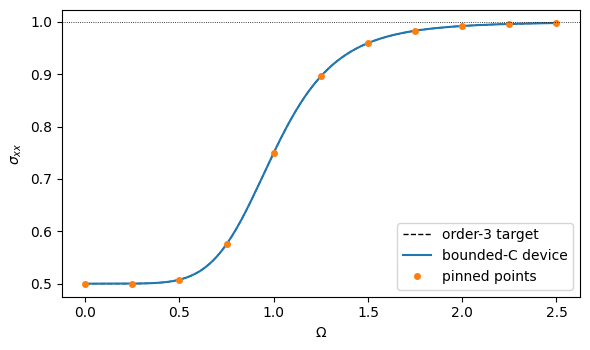

In [26]:
optimizer_b10_bounded, graph_b10_bounded, success_bounded, best_bounded = fit_named(
    problem_b10_n3, RICHER_N3, c_max=100.0, num_tests=30)

print("%s under C <= 100" % ("VALID" if success_bounded else "INVALID"))
print(parameter_summary(best_bounded, optimizer_b10_bounded.space, graph_b10_bounded))

grid = np.linspace(0.0, 2.5, 201)
achieved = spectrum_of(optimizer_b10_bounded, best_bounded["x"], grid)
plt.figure(figsize=(6, 3.6))
plt.plot(grid, butterworth_dip(grid, depth=0.5, bandwidth=1.0, order=3), "k--", lw=1,
         label="order-3 target")
plt.plot(grid, achieved, label="bounded-C device")
plt.plot(problem_b10_n3.target.omegas,
         spectrum_of(optimizer_b10_bounded, best_bounded["x"], problem_b10_n3.target.omegas),
         "o", ms=4, label="pinned points")
plt.axhline(1.0, color="k", lw=0.6, ls=":")
plt.xlabel(r"$\Omega$"); plt.ylabel(r"$\sigma_{xx}$")
plt.legend(); plt.tight_layout(); plt.show()


### The budget as a search restriction &mdash; and what it does *not* buy

Running the whole Sec. 6 search under the budget is a different claim from running it
without: "complete within this budget" rather than "complete". Note the count does not
shrink. Constraining the parameters makes *more* graphs minimal &mdash; an element that used
to be droppable is now needed to stay inside the budget &mdash; so limit points leave the list
and other architectures enter it.

The honest caveat: the cooperativity budget closes the `C, Delta -> infinity` ray, not
every ray. The decay ratios are bounded by `log_decay_ratio_bound` (default
$\tilde\kappa \le 100$) and some solutions simply run away in $\tilde\kappa$ instead,
sitting on that bound. A full "buildable devices only" declaration needs both budgets,
and they are hardware statements, not numerics.

In [27]:
t0 = time.time()
kwargs_budget = problem_b10_n3.optimizer_kwargs(kwargs_optimization={"num_tests": 10})
kwargs_budget["constraints"] = (CooperativityBudget(100.0),)
kwargs_budget["log_decay_ratio_bound"] = np.log(10.0)

optimizer_b10_budget = CovarianceArchitectureOptimizer(
    problem_b10_n3.target, num_auxiliary_modes=1, seed=SEED,
    make_initial_test=False, **kwargs_budget)
irreducibles_b10_budget = optimizer_b10_budget.perform_breadth_first_search(progress=False)

print("\nunder C <= 100 and kappa~ <= 10: %i irreducible graph(s) in %.0f s"
      % (len(irreducibles_b10_budget), time.time() - t0))
print("(unbounded search above: %i)" % len(irreducibles_b10_n3))
print()
print(solution_table(optimizer_b10_budget, irreducibles_b10_budget, limit=3))


start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 6 graphs with 9 degrees of freedom:


test 19 graphs with 8 degrees of freedom:


test 40 graphs with 7 degrees of freedom:


test 61 graphs with 6 degrees of freedom:


...

test 61 graphs with 4 degrees of freedom:


      certificate fired: passive_range
test 37 graphs with 3 degrees of freedom:


test 15 graphs with 2 degrees of freedom:


test 3 graphs with 1 degrees of freedom:


valid: 148    invalid: 160 (certified 1, uncertified 159)    oracle calls: 3781    escalations: 172
optimisation finished, list of irreducible graphs has 25 elements (159 uncertified rejections)

under C <= 100 and kappa~ <= 10: 25 irreducible graph(s) in 171 s
(unbounded search above: 20)

25 valid graph(s), with the converged parameters:

#0  complexity=4  couplings=3  pumps=3
      detuning Delta_0
      on-site squeezing 0 (real)
      two-mode squeezing 0-1 (real)
      on-site squeezing 1 (real)
      loss=9.99e-09   max Re eig(M~)=-0.5004
      cooperativities:
         C_{0,0}              +21.0227
         C^{SQZ}_{0,1}        +0.4259
         C_{1,1}              +0.0043
      phases:
         arg(nu_{0,0})        +3.1416
         arg(nu_{1,1})        +3.1416
      detunings:
         Delta_0/kappa_0      +2.4524
      decay_ratios:
         kappa~_0             +1.2347
         kappa~_1             +2.2875

#1  complexity=4  couplings=2  pumps=2
      detuning Delta_0
      

## B.11 &mdash; band-limited EPR entanglement

B.2 made spectral. The target is written on the **joint** quadratures, because that is what
"EPR-certified inside the band, separable outside" is a statement about:

$$\mathrm{Var}\!\left(\tfrac{x_1-x_2}{\sqrt2}\right)(\Omega)
= \mathrm{Var}\!\left(\tfrac{p_1+p_2}{\sqrt2}\right)(\Omega)
= 1 - (1-s_0)\,L(\Omega),$$

so the halved Duan sum is $2 - 2(1-s_0)L(\Omega)$: below the separability bound 2 exactly
where the Lorentzian window has weight. Neither joint variance is a single entry of
$\sigma_\mathrm{out}$, so these are quadratic-form pins (`pin_form`).

2 mode(s): no witness   loss = 1.17e-06   max Re eig(M~) = +0.3752


3 mode(s): VALID        loss = 9.97e-09   max Re eig(M~) = -0.0130
   graph: detuning Delta_0, beam-splitter 0-1 (complex), beam-splitter 0-2 (complex), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)
   loss=9.97e-09   max Re eig(M~)=-0.0130
   cooperativities: C_{0,0}=+2.4226  C^{BS}_{0,1}=+0.8714  C^{SQZ}_{0,1}=+1.7298  C^{BS}_{0,2}=+14.7764  C^{SQZ}_{0,2}=+0.2233  C_{1,1}=+1.0585  C^{BS}_{1,2}=+7.7335  C^{SQZ}_{1,2}=+1.9829  C_{2,2}=+4.1423
   phases:          arg(nu_{0,0})=+3.1210  arg(g_{0,1})=+2.3112  arg(nu_{0,1})=+0.1935  arg(g_{0,2})=+2.3496  arg(nu_{0,2})=-1.0785  arg(nu_{1,1})=-0.0091  arg(g_{1,2})=-0.6992  arg(nu_{1,2})=-1.7989  arg(nu_{2,2})=-2.6497
   detunings:       Delta_0/kappa_0=-0.6189  Delta_1/kappa_1=+1.4141  Delta_2/kappa_2=+0.8000
   decay_ratios:    kap

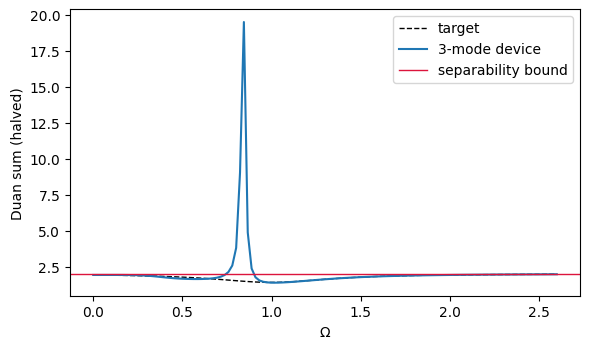

Duan 1.380 at the band centre, 1.965 at the edge of the grid
A Lorentzian window has infinite support, so off band the Duan sum only *approaches*
2 -- the certified bandwidth is quoted at a threshold.


In [28]:
depth, center, bandwidth = 0.7, 1.0, 0.4
problem_b11 = band_limited_epr(depth=depth, center=center, bandwidth=bandwidth)
optimizer_b11, info_b11, modes_b11 = mode_count_ladder(problem_b11, (0, 1))

grid = np.linspace(0.0, center + 4 * bandwidth, 121)
duan = np.array([duan_sum(np.real(optimizer_b11.oracle.covariance(info_b11["x"], w)), 0, 1) / 2.0
                 for w in grid])

plt.figure(figsize=(6, 3.6))
plt.plot(grid, duan_of_band_limited_epr(grid, depth, center, bandwidth), "k--", lw=1,
         label="target")
plt.plot(grid, duan, label="%i-mode device" % modes_b11)
plt.axhline(2.0, color="crimson", lw=1, label="separability bound")
plt.xlabel(r"$\Omega$"); plt.ylabel("Duan sum (halved)")
plt.legend(); plt.tight_layout(); plt.show()

print("Duan %.3f at the band centre, %.3f at the edge of the grid"
      % (duan.min(), duan[-1]))
print("A Lorentzian window has infinite support, so off band the Duan sum only *approaches*")
print("2 -- the certified bandwidth is quoted at a threshold.")
SUMMARY.append(("B.11 band-limited EPR", modes_b11,
                "Duan %.3f in band, %.3f out" % (duan.min(), duan[-1])))

## B.12 &mdash; notch (band-stop) squeezing

Broadband squeezing with a hole punched at a chosen line &mdash; to skip a mechanical
resonance, or to leave a readout window at the vacuum floor. The hole is a
destructive-interference zero of the squeezing enhancement, so it costs one more detuned mode
than the plain window of B.9 does: *a dip needs one resonance, a dip with a hole needs the
interfering partner*.

1 mode(s): no witness   loss = 5.49e-02   max Re eig(M~) = -1.3948


2 mode(s): no witness   loss = 2.05e-05   max Re eig(M~) = +0.8557


3 mode(s): VALID        loss = 9.99e-09   max Re eig(M~) = -0.2448
   graph: detuning Delta_0, beam-splitter 0-1 (complex), beam-splitter 0-2 (complex), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)
   loss=9.99e-09   max Re eig(M~)=-0.2448
   cooperativities: C_{0,0}=+0.8460  C^{BS}_{0,1}=+0.4774  C^{SQZ}_{0,1}=+0.5385  C^{BS}_{0,2}=+1.3514  C^{SQZ}_{0,2}=+0.4286  C_{1,1}=+0.8357  C^{BS}_{1,2}=+0.0510  C^{SQZ}_{1,2}=+0.1139  C_{2,2}=+1.6251
   phases:          arg(nu_{0,0})=-1.2288  arg(g_{0,1})=+1.4222  arg(nu_{0,1})=-1.2378  arg(g_{0,2})=+1.5913  arg(nu_{0,2})=-3.0622  arg(nu_{1,1})=-2.7932  arg(g_{1,2})=+1.7383  arg(nu_{1,2})=+2.8236  arg(nu_{2,2})=-1.5587
   detunings:       Delta_0/kappa_0=-0.1535  Delta_1/kappa_1=+0.0660  Delta_2/kappa_2=+0.5706
   decay_ratios:    kapp

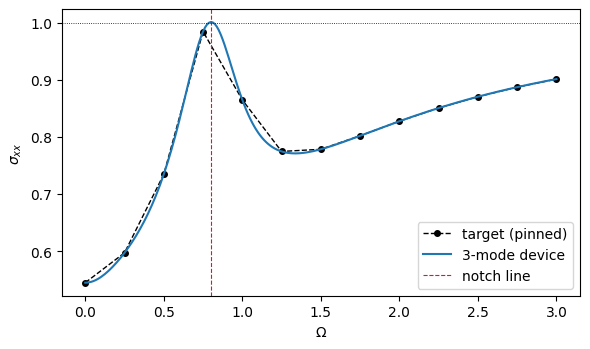

sigma_xx on the notch line 1.0013 (vacuum floor 1.0); 0.5471 / 0.7824 at +- 0.75 from it


In [29]:
notch_center, notch_width = 0.8, 0.25
problem_b12 = notch_squeezer(notch_center=notch_center, notch_width=notch_width)
optimizer_b12, info_b12, modes_b12 = mode_count_ladder(problem_b12, (0, 1, 2))

grid = np.linspace(0.0, 3.0, 241)
achieved = spectrum_of(optimizer_b12, info_b12["x"], grid)
pinned = problem_b12.target.omegas
pinned_values = [float(np.real(pin.value)) for pin in problem_b12.target.pins]

plt.figure(figsize=(6, 3.6))
plt.plot(pinned, pinned_values, "ko--", ms=4, lw=1, label="target (pinned)")
plt.plot(grid, achieved, label="%i-mode device" % modes_b12)
plt.axvline(notch_center, color="crimson", lw=0.8, ls="--", label="notch line")
plt.axhline(1.0, color="k", lw=0.6, ls=":")
plt.xlabel(r"$\Omega$"); plt.ylabel(r"$\sigma_{xx}$")
plt.legend(); plt.tight_layout(); plt.show()

at_notch = float(np.interp(notch_center, grid, achieved))
print("sigma_xx on the notch line %.4f (vacuum floor 1.0); %.4f / %.4f at +- %.2f from it"
      % (at_notch,
         float(np.interp(notch_center - 3 * notch_width, grid, achieved)),
         float(np.interp(notch_center + 3 * notch_width, grid, achieved)),
         3 * notch_width))
SUMMARY.append(("B.12 notch squeezing", modes_b12,
                "vacuum floor %.3f at the notch" % at_notch))

## Summary

In [30]:
print("%-24s %-8s %s" % ("target", "modes", "verified property"))
print("-" * 78)
for name, count, result in SUMMARY:
    print("%-24s %-8s %s" % (name, count, result))
print()
print("Every target above pins sigma_out on a frequency grid, so the decay ratios kappa~_i")
print("are live optimisation variables -- the point of the whole exercise.  One mode short of")
print("the structural minimum the fit never reaches tolerance on any restart (a *provisional*,")
print("non-condemning INVALID, Sec. 6); adding the mode flips it VALID.")
print()
print("The rotation family (B.8-imp/nm/wind) adds the other two counted resources: purity")
print("costs added noise (a live gamma_i, or an auxiliary mode's vacuum port), and rotation")
print("shape / magnitude cost modes.  Their targets are written from a declared reference")
print("device, so the prescribed quantity is measured off the spectrum, not assumed.")
print()
print("%-14s %-14s %-14s %s" % ("search", "irreducibles", "oracle calls", "uncertified"))
print("-" * 78)
for label, opt, irr in (("B.8", optimizer_b8_search, irreducibles_b8),
                        ("B.9", optimizer_b9_search, irreducibles_b9),
                        ("B.10 n=2", optimizer_b10_n2, irreducibles_b10_n2),
                        ("B.10 n=3", optimizer_b10_n3, irreducibles_b10_n3)):
    print("%-14s %-14i %-14i %i"
          % (label, len(irr), sum(opt.num_tested_graphs), opt.n_uncertified()))

target                   modes    verified property
------------------------------------------------------------------------------
B.8 squeeze rotation     1        pure at every Omega, axis sweeps pi/2
B.8-imp impure rotation  1        mu up to 1.210, gamma_0 = 0.200 live
B.8-nm turning point     2        theta turns at Omega = 0.80
B.8-wind winding         2        3.60 rad demanded vs 3.01 rad ceiling
B.9 bandpass squeezing   2        dip 0.500 at 1.00, HWHM 0.40
B.10 flat-top plateau    2        orders [1, 2, 3] -> modes [1, 1, 2]
B.11 band-limited EPR    3        Duan 1.380 in band, 1.965 out
B.12 notch squeezing     3        vacuum floor 1.001 at the notch

Every target above pins sigma_out on a frequency grid, so the decay ratios kappa~_i
are live optimisation variables -- the point of the whole exercise.  One mode short of
the structural minimum the fit never reaches tolerance on any restart (a *provisional*,
non-condemning INVALID, Sec. 6); adding the mode flips it VALID.

The